In [1]:
# Динамический импорт и инициализация библиотек и путей для работы с данными в Python <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
from pathlib import Path
import csv
import sys
import os
import pandas as pd
import json
from clickhouse_driver import Client
import gc
import numpy as np
import glob
from collections import Counter
import re
from datetime import datetime

In [2]:
file_dir = os.getcwd()                                                              # Определяем путь к текущему файлу (где выполняется код)
print(f"📂 Директория файла:                                      {file_dir}")

sub_project_dir = Path(file_dir).parent
print(f"📂 Директория СубПроекта:                     {sub_project_dir}")

project_dir                     = Path(file_dir).parent.parent.parent               # Переход в верхнюю директорию проекта (fc_to_mt5_migrations/own_platform)
print(f"📂 Рабочая директория проекта:                             {project_dir}")

parent_dir                      = Path.cwd().parent.parent.parent.parent            # Переход на уровень выше (fc_to_mt5_migrations)
print(f"📂 Рабочая директория проекта для доступа к библиотекам:   {parent_dir}")


# Функция для проверки существования директории и её создания при отсутствии <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
def ensure_directory(path, description="", name=""):
    if not os.path.isdir(path):
        os.makedirs(path)
        print(f"❗📁 [{name}] не найден, создан новый каталог: {os.path.abspath(path)}")
    else:
        print(f"📁 [{name}]; {description}: {os.path.abspath(path)}")
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

input_log_data = os.path.join(project_dir, sub_project_dir, "input_data", 'input_log_data'); ensure_directory(input_log_data, "Путь к каталогу с логами исходных файлов", "input_log_data")
print(f"📁 [input_log_data];     Путь к каталогу с историей исходных данных:{input_log_data}"); os.makedirs("tests/fixtures", exist_ok=True)

input_temp_data = os.path.join(project_dir, sub_project_dir, "input_data", 'input_temp_data')           # Путь к каталогу с входными временными файлами
print(f"📁 [input_temp_data];    Путь к каталогу с исходными данными:{input_temp_data}")
input_samples_data = os.path.join(project_dir, sub_project_dir, "input_data", 'input_samples')     # Путь к каталогу с входными примерами данных
print(f"📁 [input_samples_data]; Путь к каталогу с примерами данных: {input_samples_data}")

directory_data_log_files        = os.path.join(project_dir, sub_project_dir, 'log_data_files')
print(f"📁 [directory_data_log_files];     Путь к каталогу с лог-файлами:                          {directory_data_log_files}")

directory_data_temp_files       = os.path.join(project_dir, sub_project_dir, 'working_data_files') 
print(f"📁 [directory_data_temp_files];    Путь к каталогу с временными файлами:                   {directory_data_temp_files}")

directory_data_original_data    = os.path.join(project_dir, 'original_data')        # Путь к каталогу с оригинальными данными
print(f"📁 Путь к каталогу с оригинальными данными:                {directory_data_original_data}")

directory_data_set              = os.path.join(project_dir, 'data_set')             # Путь к каталогу с конфигурационными данными
print(f"📁 Путь к каталогу с файлами настроек:                     {directory_data_set}")

directory_data_output           = os.path.join(parent_dir, 'output_data')           # Путь к каталогу с выходными данными

libraries_path = os.path.join(parent_dir, "libraries_py")                           # Формируем путь к libraries_py каталогу с библиотеками *.py
sys.path.append(libraries_path)                                                     # sys.path — это список путей, где Python ищет модули при import module_name.

📂 Директория файла:                                      c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\Reading\ipynb_files
📂 Директория СубПроекта:                     c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\Reading
📂 Рабочая директория проекта:                             c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform
📂 Рабочая директория проекта для доступа к библиотекам:   c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations
📁 [input_log_data]; Путь к каталогу с логами исходных файлов: c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\Reading\input_data\input_log_data
📁 [input_log_data];     Путь к каталогу с историей исходных данных:c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\Reading\input_data\input_log_data
📁 [input_temp_data];    Путь к каталогу с исходным

In [3]:
if libraries_path in sys.path: print(f"✅ Каталог {libraries_path} успешно добавлен в sys.path")
else: print(f"❌ Ошибка: {libraries_path} не найден в sys.path")

# Динамически импорт необходимых функций <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
file_imports = "dynamic_import_functions.py"                                        # Библиотека для динамического импорта
file_imports_path = os.path.join(libraries_path, file_imports)
if os.path.exists(file_imports_path):
    import importlib
    importlib.invalidate_caches()                                                   # Сбрасываем кэш перед импортом
    from dynamic_import_functions import import_functions, print_import_function_info
    print(f"\n ✅ Импорт [{file_imports}] успешен.")
else:
    print(f"\n ERROR: Файл '{file_imports}' не найден по пути {file_imports_path}, импорт не выполнен.\n")

modules_to_import = {                                                           # Формируем словарь, с именами файлов и функциями в них
    "yar_sed_general_lib":
        [libraries_path,
                "pd_set_option",                        # Вывод ДФ
                "df_to_csv",                            # Сохранение ДФ в CSV 
                "CSVLoader",
                "save_data_log_work_file",
                "detect_encoding",
                "time_to_minutes",
                "load_string_list",
                "list_print",
                "move_column"],
    "sql_request_2":
        [libraries_path, 
                "pd_read_sql",
                "get_sql_tab"]
                }

imported = import_functions(modules_to_import)          # Импортируем модули из словаря modules_to_import

print_import_function_info(modules_to_import, imported) # Выводим переменные ожидаемые импортированными функциями 

✅ Каталог c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\libraries_py успешно добавлен в sys.path

 ✅ Импорт [dynamic_import_functions.py] успешен.
Импорт из 'yar_sed_general_lib' успешен: ['pd_set_option', 'df_to_csv', 'CSVLoader', 'save_data_log_work_file', 'detect_encoding', 'time_to_minutes', 'load_string_list', 'list_print', 'move_column']
Импорт из 'sql_request_2' успешен: ['pd_read_sql', 'get_sql_tab']

 Импортированные функции и их параметры:
Функция 'pd_set_option' из модуля 'yar_sed_general_lib' ожидает параметры: name_df: str, df: pandas.core.frame.DataFrame, rows: int = 10, columns: int | None = None, min_rows: int | None = None, width: int = 100
Функция 'df_to_csv' из модуля 'yar_sed_general_lib' ожидает параметры: df, csv_file_path
Функция 'CSVLoader' из модуля 'yar_sed_general_lib' ожидает параметры: file_path, delimiter=';', encoding='utf-8', df_name='dataframe'
Функция 'save_data_log_work_file' из модуля 'yar_sed_general_lib' ожидает параметры: df, file_n

In [4]:
# Преобразует текстовое расписание торговых сессий в множество (set) минут дня. <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
def get_minutes_from_session(session_str):
    """Преобразует текстовое расписание торговых сессий в множество (set) минут дня.
    Логика работы:
    1. Принимает строку расписания, поддерживая мульти-сессии через разделитель <br>.
    2. Каждое время формата ЧЧ:ММ переводит в абсолютную минуту дня (от 0 до 1439).
    3. Создает диапазон минут от начала до конца каждой сессии включительно.
    4. Возвращает уникальное множество всех "разрешенных" минут для быстрой проверки вхождения.
    
    Пример: "08:00-09:00" -> {480, 481, ..., 540}
    """
    if not isinstance(session_str, str) or not session_str.strip():
        return set()
    minutes_in_session = set()
    parts = session_str.replace('<br>', '\n').split('\n')
    for part in parts:
        if '-' in part:
            try:
                s, e = part.strip().split('-')
                start_total = int(s.split(':')[0]) * 60 + int(s.split(':')[1])
                end_total = int(e.split(':')[0]) * 60 + int(e.split(':')[1])
                for m in range(start_total, end_total + 1):
                    minutes_in_session.add(m)
            except: continue
    return minutes_in_session

# Преобразует поминутную карту плотности в список временных интервалов <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
def get_intervals(series, min_duration = 5):    
    """Преобразует поминутную карту плотности в список временных интервалов.
    Логика:
    1. Проходит по значениям серии и фиксирует моменты изменения состояния (Active <-> Gap).
    2. Если текущее состояние длится дольше min_duration, формируется строка "начало-конец".
    3. Интервалы классифицируются как 'Quotes_Presence' (наличие) или 'Quotes_Absence' (отсутствие).
    
    Пример выхода: "04.20.13:30-04.20.20:14"
    """
    active_intervals = []
    gap_intervals = []
    
    if series.empty: return "", ""

    times = series.index.tolist()
    values = series.values
    start_idx = 0
    is_active = values[0] > 0
    
    for i in range(1, len(values)):
        current_state = values[i] > 0
        if current_state != is_active:
            duration = i - start_idx                                                # Вычисляем длительность интервала в минутах
            
            if duration > min_duration:                                             # Регистрируем только если длительность больше порога
                interval_str = f"{times[start_idx]}-{times[i-1]}"
                if is_active: active_intervals.append(interval_str)
                else: gap_intervals.append(interval_str)
            
            start_idx = i
            is_active = current_state
            
    last_duration = len(values) - start_idx                                         # Проверка для последнего интервала
    if last_duration > min_duration:
        last_interval = f"{times[start_idx]}-{times[-1]}"
        if is_active: active_intervals.append(last_interval)
        else: gap_intervals.append(last_interval)
        
    return "<br>".join(active_intervals), "<br>".join(gap_intervals)



# Вспомогательная функция (или просто вынесите логику append)
def _append_outside_report(self, container, symbol, full_interval, block, sched_text, weekday):
    v_start = f"{block[0]//60:02d}:{block[0]%60:02d}"
    v_end = f"{block[-1]//60:02d}:{block[-1]%60:02d}"
    duration = block[-1] - block[0] + 1
    
    container.append({
        'Ticker': symbol,
        'Full_Interval': full_interval,
        'Violation_Period': f"{v_start}-{v_end}",
        'Duration_Min': duration,
        'Schedule_Applied': sched_text,
        'Weekday': weekday,
        'Type': 'Outside Session'
    })



# [Функция] (передаем df_sessions для получения отчёта по наличию / отсутствию котировок в разрезе расписания) <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
def analyze_status_intervals_v2(df_status, schedule_map, analysis_year, df_sessions):
    low_activity = []
    outside_activity = []

    # Создаем быстрый поиск расписания в текстовом виде для отчета
    raw_schedule = df_sessions.set_index('name_s')

    for _, row in df_status.iterrows():
        symbol = row['Ticker']
        if symbol not in schedule_map: continue


        # --- 1. ПРОВЕРКА ВНЕ СЕССИИ (Presence) ---
        if row['Quotes_Presence']:
            for interval in row['Quotes_Presence'].split('<br>'):
                start_str, end_str = interval.split('-')
                
                # Парсим полные объекты даты/времени для корректного сравнения суток
                dt_start = pd.to_datetime(f"{analysis_year}.{start_str}", format='%Y.%m.%d.%H.%M')
                dt_end = pd.to_datetime(f"{analysis_year}.{end_str}", format='%Y.%m.%d.%H.%M')
                
                csv_weekday = (dt_start.weekday() + 1) % 7
                allowed_mins = schedule_map[symbol][csv_weekday]
                sched_text = raw_schedule.loc[symbol, f"1_{csv_weekday}"]

                # Считаем базовые минуты
                start_total = dt_start.hour * 60 + dt_start.minute
                end_total = dt_end.hour * 60 + dt_end.minute
                
                # !!! НЮАНС: Обработка перехода через полночь !!!
                if dt_end.date() > dt_start.date():
                    # Если интервал захватил следующий день, увеличиваем конечную точку на 24 часа
                    days_diff = (dt_end.date() - dt_start.date()).days
                    end_total += 1440 * days_diff
                
                # Теперь range отработает корректно (например, от 1349 до 1697 минут)
                violation_mins = [m for m in range(start_total, end_total + 1) if (m % 1440) not in allowed_mins]
                
                if violation_mins:
                    current_block = [violation_mins[0]]
                    for i in range(1, len(violation_mins)):
                        if violation_mins[i] - violation_mins[i-1] > 1:
                            # При выводе используем остаток от деления на 1440, чтобы время не превышало 23:59
                            m0, mN = current_block[0] % 1440, current_block[-1] % 1440
                            v_start = f"{m0//60:02d}:{m0%60:02d}"
                            v_end = f"{mN//60:02d}:{mN%60:02d}"
                            
                            outside_activity.append({
                                'Ticker': symbol,
                                'Full_Interval': interval,
                                'Violation_Period': f"{v_start}-{v_end}",
                                'Duration_Min': len(current_block),
                                'Schedule_Applied': sched_text,
                                'Weekday': csv_weekday,
                                'Type': 'Outside Session'
                            })
                            current_block = []
                        current_block.append(violation_mins[i])
                    
                    if current_block:
                        m0, mN = current_block[0] % 1440, current_block[-1] % 1440
                        v_start = f"{m0//60:02d}:{m0%60:02d}"
                        v_end = f"{mN//60:02d}:{mN%60:02d}"
                        outside_activity.append({
                            'Ticker': symbol,
                            'Full_Interval': interval,
                            'Violation_Period': f"{v_start}-{v_end}",
                            'Duration_Min': len(current_block),
                            'Schedule_Applied': sched_text,
                            'Weekday': csv_weekday,
                            'Type': 'Outside Session'
                        })





        # --- 2. ПРОВЕРКА ДЫР ВНУТРИ СЕССИИ (Absence) ---
        if row['Quotes_Absence']:
            for interval in row['Quotes_Absence'].split('<br>'):
                start_str, end_str = interval.split('-')
                dt_start = pd.to_datetime(f"{analysis_year}.{start_str}", format='%Y.%m.%d.%H.%M')
                csv_weekday = (dt_start.weekday() + 1) % 7
                allowed_mins = schedule_map[symbol][csv_weekday]
                sched_text = raw_schedule.loc[symbol, f"1_{csv_weekday}"]
                #if symbol == 'CA60': print(sched_text)
                s_h, s_m = map(int, start_str.split('.')[-2:])
                e_h, e_m = map(int, end_str.split('.')[-2:])
                start_total, end_total = s_h * 60 + s_m, e_h * 60 + e_m

                gap_violation = [m for m in range(start_total, end_total + 1) if m in allowed_mins]
                
                if gap_violation:
                    gv_start = f"{gap_violation[0]//60:02d}:{gap_violation[0]%60:02d}"
                    gv_end = f"{gap_violation[-1]//60:02d}:{gap_violation[-1]%60:02d}"
                    # Длительность: разница между последней и первой минутой пропуска + 1
                    duration = gap_violation[-1] - gap_violation[0] + 1
                    #if symbol == 'CA60': print("duration ", duration)
                    low_activity.append({
                        'Ticker': symbol,
                        'Full_Interval': interval,
                        'Gap_Period': f"{gv_start}-{gv_end}",
                        'Duration_Min': duration,  # Новая колонка
                        'Schedule_Applied': sched_text,
                        'Weekday': csv_weekday,
                        'Type': 'Gap in Session'
                    })
    return pd.DataFrame(low_activity), pd.DataFrame(outside_activity)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

# [ Функция ] фильтрации интервалов более [duration_threshold] минут <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
def filter_by_duration(df, interval_col, duration_threshold=-1):        # Оставляем только интервалы более [duration_threshold] минут
    df_gaps = df[(pd.to_timedelta(df[interval_col].str.split('-').str[1] + ':00') -  pd.to_timedelta(df[interval_col].str.split('-').str[0] + ':00')
                ).dt.total_seconds() / 60 > duration_threshold]
    return df_gaps
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>    

def add_stats_to_outside_report(df_outside, df_density):
    """
    Рассчитывает статистику активности (среднее и медиану) для каждого выявленного нарушения.
    
    Логика работы:
    1. Автоматически определяет префикс даты из матрицы плотности (поддержка мультидатовых файлов).
    2. Динамически ищет колонку с временным интервалом нарушения (Period/Interval).
    3. Для каждой строки отчета делает "срез" данных из df_density, используя строковое 
       сопоставление имен колонок (формат MM.DD.HH.MM).
    4. Рассчитывает среднее (Mean) и медиану (Median) количества тиков в указанном окне.
    5. Сортирует результат по тикерам и дням недели для удобства анализа серийных сбоев.
    
    Результат:
    Добавляет две новые колонки: 'Avg_Ticks_Outside' и 'Med_Ticks_Outside'.
    """
    if df_outside.empty:
        return df_outside

    # 1. Определяем префикс даты (например, '04.20.') из колонок матрицы
    # Это позволит коду работать с любым днем
    date_prefix = df_density.columns[0][:6] 
    
    # 2. Определяем имя колонки с интервалом (Violation_Period или Gap_Period)
    target_col = next((c for c in ['Violation_Period', 'Violation_Interval', 'Gap_Period'] if c in df_outside.columns), None)
    
    if not target_col:
        print("❌ Ошибка: Не найдена колонка с временным интервалом")
        return df_outside

    def get_row_stats(row):
        ticker = row['Ticker']
        period = row[target_col]
        
        # Базовые проверки
        if ticker not in df_density.index or not isinstance(period, str) or '-' not in period:
            return 0.0, 0.0
        
        try:
            # Превращаем "00:01-00:05" в "04.20.00.01" и "04.20.00.05"
            start_t, end_t = period.split('-')
            full_start = f"{date_prefix}{start_t.replace(':', '.')}"
            full_end = f"{date_prefix}{end_t.replace(':', '.')}"
            
            # Выбираем все колонки из df_density, которые попадают в этот диапазон
            # Это сработает даже если у вас 7200 колонок (детализация выше минуты)
            mask = (df_density.columns >= full_start) & (df_density.columns <= full_end)
            data_slice = df_density.loc[ticker, mask]
            
            if data_slice.empty:
                return 0.0, 0.0
            
            return round(data_slice.mean(), 2), round(data_slice.median(), 2)
        except:
            return 0.0, 0.0

    result_df = df_outside.copy()                                                       # Создаем копию и применяем расчет
    
    stats = result_df.apply(get_row_stats, axis=1)                                      # Применяем функцию и распределяем результат по двум новым колонкам
    result_df['Avg_Ticks_Outside'], result_df['Med_Ticks_Outside'] = zip(*stats)
    
    result_df = result_df.sort_values(by=['Ticker', 'Weekday']) # Упорядочить сначала по target_symbolу, а затем по Weekday

    return result_df

def get_symbol_violations_report_v2(df_gaps, df_extra, target_ticker):
    """
    Создает сводный отчет о нарушениях для конкретного тикера, классифицируя их по положению относительно торговой сессии.
    
    Логика работы:
    1. Извлекает данные из двух источников: df_gaps (пропуски внутри сессии) и df_extra (активность вне сессии).
    2. Унифицирует названия колонок для возможности объединения (concat).
    3. Вычисляет "позицию" нарушения (Position):
       - Для Gap in Session: определяет, произошел ли пропуск на открытии (Start), закрытии (End) или в середине сессии (Middle).
       - Для Outside Session: классифицирует данные как Pre-Open (перед открытием), Post-Close (после закрытия) или просто Outside.
    4. Парсит строку расписания Schedule_Applied, корректно обрабатывая сложные сессии с перерывами (<br>).
    5. Сортирует все инциденты хронологически по дням недели и времени начала нарушения.
    
    Результат:
    DataFrame с колонками: Full_Interval, Violation_Interval, Duration_Min, Position, Schedule_Applied, Weekday, Type.
    """
    gaps_sub = df_gaps[df_gaps['Ticker'] == target_ticker].copy()
    extra_sub = df_extra[df_extra['Ticker'] == target_ticker].copy()
    
    # Унифицируем колонки интервалов
    gaps_sub = gaps_sub.rename(columns={'Gap_Period': 'Violation_Interval'})
    extra_sub = extra_sub.rename(columns={'Violation_Period': 'Violation_Interval'})
    
    combined_df = pd.concat([gaps_sub, extra_sub], ignore_index=True)
    if combined_df.empty:
        return combined_df

    def detect_position(row):
        try:
            # Парсим время нарушения (например, 13:30-13:51)
            v_start, v_end = row['Violation_Interval'].split('-')
            
            # Парсим расписание (берем первую и последнюю сессию, если их несколько)
            # Например, "13:30-20:59" или "00:00-19:59<br>21:00-23:59"
            sched_parts = row['Schedule_Applied'].replace('<br>', '-').split('-')
            s_start = sched_parts[0]
            s_end = sched_parts[-1]

            # Логика для пропусков (Gaps)
            if row['Type'] == 'Gap in Session':
                if v_start == s_start: return "Start"
                if v_end == s_end: return "End"
                return "Middle"
            
            # Логика для лишних данных (Outside)
            else: 
                # Если лишние данные закончились ровно в момент открытия рынка
                if v_end == s_start: return "Pre-Open"
                # Если лишние данные начались ровно в момент закрытия рынка
                if v_start == s_end: return "Post-Close"
                return "Outside"
        except:
            return "Unknown"

    # Применяем определение позиции
    combined_df['Position'] = combined_df.apply(detect_position, axis=1)
    
    # Финальная сборка
    final_cols = ['Full_Interval', 'Violation_Interval', 'Duration_Min', 'Position', 'Schedule_Applied', 'Weekday', 'Type']
    
    # Сортировка по времени
    combined_df['sort_time'] = combined_df['Violation_Interval'].str.split('-').str[0]
    result = combined_df[final_cols + ['sort_time']].sort_values(['Weekday', 'sort_time'])
    
    return result.drop(columns=['sort_time'])

In [ ]:
# Собираем выкаченнуб статистику в один ДФ <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

# --- НАСТРОЙКИ ИНТЕРВАЛА ---
date_start_limit = "2026-04-19"                                 # С какой даты начинаем (включительно)
date_end_limit   = "2026-04-24"                                 # По какую дату заканчиваем (включительно)
folder_mask = "Monitor_quotes_according_session"                # маска дирректории с двнными

limit_start = datetime.strptime(date_start_limit, "%Y-%m-%d")   # Конвертируем границы в объекты даты для сравнения
limit_end   = datetime.strptime(date_end_limit, "%Y-%m-%d")

all_dfs = []

if os.path.exists(directory_data_temp_files):                                   # 1. Получаем список всех подкаталогов в directory_data_temp_files
    subdirs = [d for d in os.listdir(directory_data_temp_files) 
               if os.path.isdir(os.path.join(directory_data_temp_files, d))]
    print(f"🔍 Найдено всего папок в temp: {len(subdirs)}")
    
    valid_folders = []                                                          # 2. Фильтруем папки по маске и дате
    for folder in subdirs:
        if folder.endswith(folder_mask):
            # Вычленяем дату из названия папки
            match = re.search(r'(\d{4}-\d{2}-\d{2})', folder)
            if match:
                folder_date_str = match.group(1)
                folder_date = datetime.strptime(folder_date_str, "%Y-%m-%d")
                
                # Проверяем вхождение в интервал
                if limit_start <= folder_date <= limit_end:
                    valid_folders.append(folder)
    
    print(f"📂 Папок подходящих под критерии (*{folder_mask}): {len(valid_folders)}")
    
    # 3. Словарь для хранения данных: { 'EURUSD': Series_с_данными, ... }
    symbols_accumulator = {}

    for folder in sorted(valid_folders):
        save_path = os.path.join(directory_data_temp_files, folder)
        files = glob.glob(os.path.join(save_path, "*.json"))
        print(f"📄 Обработка каталога: 📂 {folder}; ✅ Найдено JSON файлов: {len(files)}")
        
        for f in files:
            try:
                with open(f, 'r', encoding='utf-8') as j:
                    data = json.load(j)
                    if data:
                        sym = list(data.keys())[0]
                        new_data = pd.Series(data[sym], name=sym)
                        
                        if sym in symbols_accumulator:                                                  # Если тикер уже есть, объединяем данные (update). 
                            symbols_accumulator[sym] = symbols_accumulator[sym].combine_first(new_data) # fillna(0) или просто update, чтобы заполнить пропуски за новый день
                        else:
                            symbols_accumulator[sym] = new_data
            except Exception as e: print(f"❌ERROR: Ошибка при чтении файла {f}: {e}")

    if symbols_accumulator:                                                             # 4. Сборка итогового DataFrame из значений словаря
        df_density = pd.DataFrame.from_dict(symbols_accumulator, orient='index')        # Теперь количество строк будет строго равно количеству уникальных тикеров
        print(f"\n✅Success: Итоговый df_density сформирован; 📊 Уникальных тикеров: {len(df_density)}")
    else:
        print("\n❌ERROR: Данные не найдены.")
        df_density = pd.DataFrame()

else:
    print(f"❌ERROR: Базовый каталог temp_files НЕ найден: {directory_data_temp_files}")
    df_density = pd.DataFrame()

imported["pd_set_option"]("df_density", df_density, 5)

🔍 Найдено всего папок в temp: 7
📂 Папок подходит под критерии: 6
📄 Обработка каталога: 📂 2026-04-19 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641
📄 Обработка каталога: 📂 2026-04-20 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641
📄 Обработка каталога: 📂 2026-04-21 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641
📄 Обработка каталога: 📂 2026-04-22 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641
📄 Обработка каталога: 📂 2026-04-23 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641
📄 Обработка каталога: 📂 2026-04-24 Monitor_quotes_according_session; 📄 Найдено JSON файлов: 1641

✅Success: Итоговый df_density сформирован; 📊 Уникальных тикеров: 1641

df_density  (1,641 строк × 8,640 колонок)


,04.19.00.00,04.19.00.01,04.19.00.02,04.19.00.03,04.19.00.04,04.19.00.05,04.19.00.06,04.19.00.07,04.19.00.08,04.19.00.09,04.19.00.10,04.19.00.11,04.19.00.12,04.19.00.13,04.19.00.14,04.19.00.15,04.19.00.16,04.19.00.17,04.19.00.18,04.19.00.19,04.19.00.20,04.19.00.21,04.19.00.22,04.19.00.23,04.19.00.24,04.19.00.25,04.19.00.26,04.19.00.27,04.19.00.28,04.19.00.29,04.19.00.30,04.19.00.31,04.19.00.32,04.19.00.33,04.19.00.34,04.19.00.35,04.19.00.36,04.19.00.37,04.19.00.38,04.19.00.39,04.19.00.40,04.19.00.41,04.19.00.42,04.19.00.43,04.19.00.44,04.19.00.45,04.19.00.46,04.19.00.47,04.19.00.48,04.19.00.49,04.19.00.50,04.19.00.51,04.19.00.52,04.19.00.53,04.19.00.54,04.19.00.55,04.19.00.56,04.19.00.57,04.19.00.58,04.19.00.59,04.19.01.00,04.19.01.01,04.19.01.02,04.19.01.03,04.19.01.04,04.19.01.05,04.19.01.06,04.19.01.07,04.19.01.08,04.19.01.09,04.19.01.10,04.19.01.11,04.19.01.12,04.19.01.13,04.19.01.14,04.19.01.15,04.19.01.16,04.19.01.17,04.19.01.18,04.19.01.19,04.19.01.20,04.19.01.21,04.19.01.22,04.19.01.23,04.19.01.24,04.19.01.25,04.19.01.26,04.19.01.27,04.19.01.28,04.19.01.29,04.19.01.30,04.19.01.31,04.19.01.32,04.19.01.33,04.19.01.34,04.19.01.35,04.19.01.36,04.19.01.37,04.19.01.38,04.19.01.39,04.19.01.40,04.19.01.41,04.19.01.42,04.19.01.43,04.19.01.44,04.19.01.45,04.19.01.46,04.19.01.47,04.19.01.48,04.19.01.49,04.19.01.50,04.19.01.51,04.19.01.52,04.19.01.53,04.19.01.54,04.19.01.55,04.19.01.56,04.19.01.57,04.19.01.58,04.19.01.59,04.19.02.00,04.19.02.01,04.19.02.02,04.19.02.03,04.19.02.04,04.19.02.05,04.19.02.06,04.19.02.07,04.19.02.08,04.19.02.09,04.19.02.10,04.19.02.11,04.19.02.12,04.19.02.13,04.19.02.14,04.19.02.15,04.19.02.16,04.19.02.17,04.19.02.18,04.19.02.19,04.19.02.20,04.19.02.21,04.19.02.22,04.19.02.23,04.19.02.24,04.19.02.25,04.19.02.26,04.19.02.27,04.19.02.28,04.19.02.29,04.19.02.30,04.19.02.31,04.19.02.32,04.19.02.33,04.19.02.34,04.19.02.35,04.19.02.36,04.19.02.37,04.19.02.38,04.19.02.39,04.19.02.40,04.19.02.41,04.19.02.42,04.19.02.43,04.19.02.44,04.19.02.45,04.19.02.46,04.19.02.47,04.19.02.48,04.19.02.49,04.19.02.50,04.19.02.51,04.19.02.52,04.19.02.53,04.19.02.54,04.19.02.55,04.19.02.56,04.19.02.57,04.19.02.58,04.19.02.59,04.19.03.00,04.19.03.01,04.19.03.02,04.19.03.03,04.19.03.04,04.19.03.05,04.19.03.06,04.19.03.07,04.19.03.08,04.19.03.09,04.19.03.10,04.19.03.11,04.19.03.12,04.19.03.13,04.19.03.14,04.19.03.15,04.19.03.16,04.19.03.17,04.19.03.18,04.19.03.19,04.19.03.20,04.19.03.21,04.19.03.22,04.19.03.23,04.19.03.24,04.19.03.25,04.19.03.26,04.19.03.27,04.19.03.28,04.19.03.29,04.19.03.30,04.19.03.31,04.19.03.32,04.19.03.33,04.19.03.34,04.19.03.35,04.19.03.36,04.19.03.37,04.19.03.38,04.19.03.39,04.19.03.40,04.19.03.41,04.19.03.42,04.19.03.43,04.19.03.44,04.19.03.45,04.19.03.46,04.19.03.47,04.19.03.48,04.19.03.49,04.19.03.50,04.19.03.51,04.19.03.52,04.19.03.53,04.19.03.54,04.19.03.55,04.19.03.56,04.19.03.57,04.19.03.58,04.19.03.59,04.19.04.00,04.19.04.01,04.19.04.02,04.19.04.03,04.19.04.04,04.19.04.05,04.19.04.06,04.19.04.07,04.19.04.08,04.19.04.09,04.19.04.10,04.19.04.11,04.19.04.12,04.19.04.13,04.19.04.14,04.19.04.15,04.19.04.16,04.19.04.17,04.19.04.18,04.19.04.19,04.19.04.20,04.19.04.21,04.19.04.22,04.19.04.23,04.19.04.24,04.19.04.25,04.19.04.26,04.19.04.27,04.19.04.28,04.19.04.29,04.19.04.30,04.19.04.31,04.19.04.32,04.19.04.33,04.19.04.34,04.19.04.35,04.19.04.36,04.19.04.37,04.19.04.38,04.19.04.39,04.19.04.40,04.19.04.41,04.19.04.42,04.19.04.43,04.19.04.44,04.19.04.45,04.19.04.46,04.19.04.47,04.19.04.48,04.19.04.49,04.19.04.50,04.19.04.51,04.19.04.52,04.19.04.53,04.19.04.54,04.19.04.55,04.19.04.56,04.19.04.57,04.19.04.58,04.19.04.59,04.19.05.00,04.19.05.01,04.19.05.02,04.19.05.03,04.19.05.04,04.19.05.05,04.19.05.06,04.19.05.07,04.19.05.08,04.19.05.09,04.19.05.10,04.19.05.11,04.19.05.12,04.19.05.13,04.19.05.14,04.19.05.15,04.19.05.16,04.19.05.17,04.19.05.18,04.19.05.19,04.19.05.20,04.19.05.21,04.19.05.22,04.19.05.23,04.19.05.24,04.19.05.25,04.19.05.26,04.19.05.27,04.19.05.28,04.19.05.29,04.19.05.30,04.19.05.31,04.19.05.32,04.

C:\Users\nigilist\AppData\Local\Temp\ipykernel_17012\2852974673.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_hourly = df_hourly.groupby(level=0, axis=1).sum()                                # Группируем колонки с одинаковыми часами и суммируем значения (кол-во котировок)


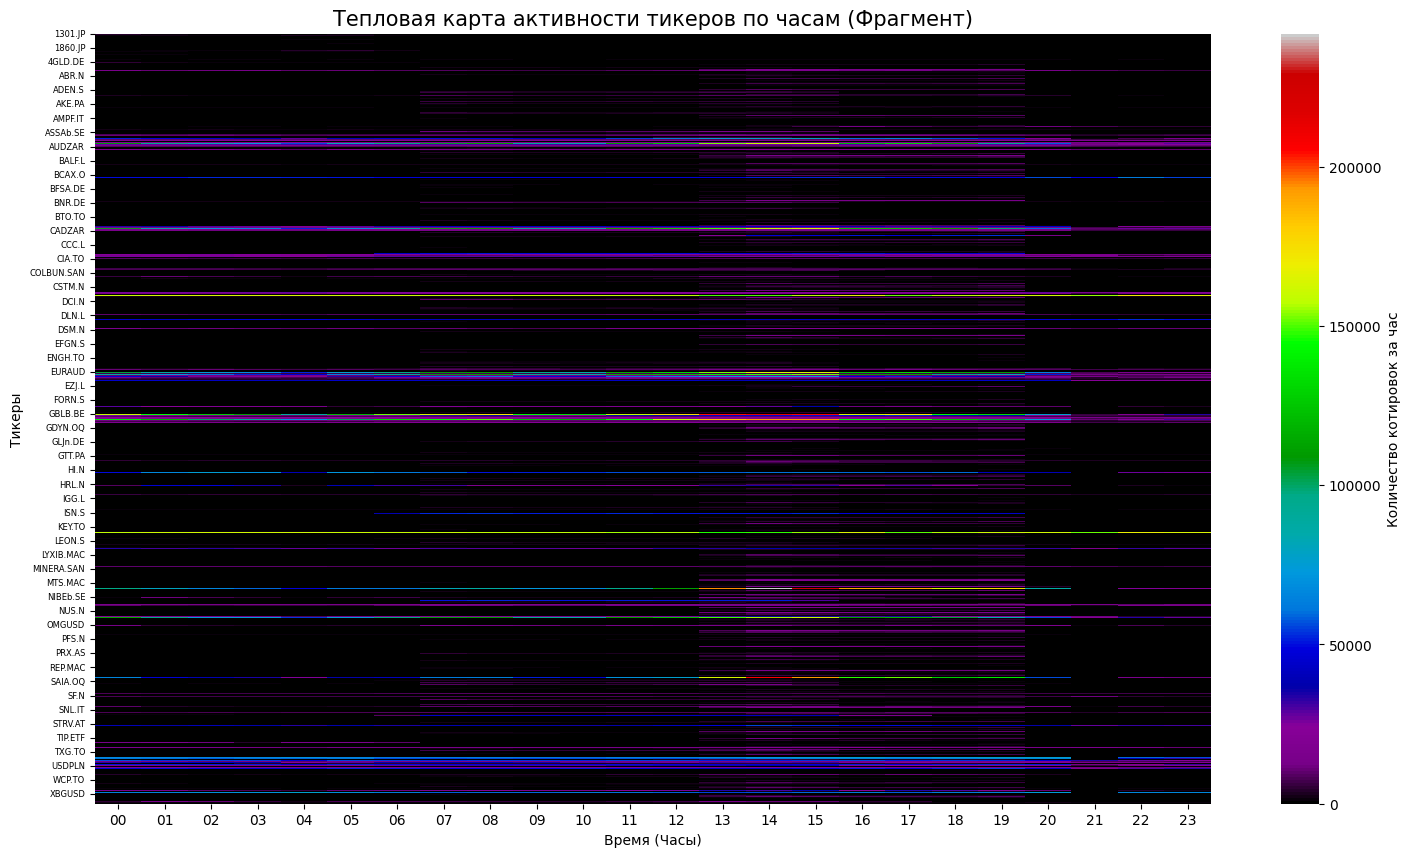

In [29]:
# Построение Тепловой карты активности тикеров по часам <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# '''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_hourly = df_density.copy()                                                       # 1. Агрегация данных по часам # Создаем копию для трансформации
df_hourly.columns = [col.split('.')[2] for col in df_hourly.columns]                # Названия колонок в формат Час (HH), # Из '04.20.15.30' получаем '15'
df_hourly = df_hourly.groupby(level=0, axis=1).sum()                                # Группируем колонки с одинаковыми часами и суммируем значения (кол-во котировок)

subset_tickers = df_hourly.index[:2000]                                             # Тикеров 1641, на одной карте все не поместятся. Выберем топ-50 или срез.
df_plot = df_hourly.loc[subset_tickers]

plt.figure(figsize=(18, 10))                                                        # 3. Построение тепловой карты
sns.heatmap(df_plot, 
            annot=False,                                                            # Установите True, если хотите видеть цифры в ячейках
            cmap="nipy_spectral",                                                   # Цветовая схема: от желтого к синему
            cbar_kws={'label': 'Количество котировок за час'})

plt.title(f"Тепловая карта активности тикеров по часам (Фрагмент)", fontsize=15)
plt.yticks(fontsize=6)
plt.xlabel("Время (Часы)", fontsize=10)
plt.ylabel("Тикеры", fontsize=10)
plt.xticks(rotation=0)
plt.show()

In [ ]:
# [ НЕ обязателен ] Технический код для контроля данных <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# '''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
target_ticker = 'AUS200'                                                        # 1. Задаем параметры фильтрации
start_date  = '04.19.21.55' 
end_date    = '04.19.23.59'

ticker_data = df_density.loc[target_ticker, start_date:end_date]              # Фильтруем: .loc[строка, столбцы]
ticker_data_df = pd.DataFrame(ticker_data).transpose()                      # Превращаем в DataFrame для вывода
imported["pd_set_option"]("ticker_data_df", ticker_data_df, 5)

ticker_series = df_density.loc[target_ticker, start_date:end_date]          # 2. Делаем срез. Результат — Series.
ticker_df_vertical = ticker_series.to_frame(name='Tick_Count')              # 3. Превращаем в DF (колонку), .to_frame() создаст DF с одной колонкой, где индексом будут даты
imported["pd_set_option"]("ticker_df_vertical", ticker_df_vertical, 200)    # 4. Теперь вызываем вашу функцию — теперь атрибут .columns существует


ticker_data_df  (1 строк × 125 колонок)


,04.19.21.55,04.19.21.56,04.19.21.57,04.19.21.58,04.19.21.59,04.19.22.00,04.19.22.01,04.19.22.02,04.19.22.03,04.19.22.04,04.19.22.05,04.19.22.06,04.19.22.07,04.19.22.08,04.19.22.09,04.19.22.10,04.19.22.11,04.19.22.12,04.19.22.13,04.19.22.14,04.19.22.15,04.19.22.16,04.19.22.17,04.19.22.18,04.19.22.19,04.19.22.20,04.19.22.21,04.19.22.22,04.19.22.23,04.19.22.24,04.19.22.25,04.19.22.26,04.19.22.27,04.19.22.28,04.19.22.29,04.19.22.30,04.19.22.31,04.19.22.32,04.19.22.33,04.19.22.34,04.19.22.35,04.19.22.36,04.19.22.37,04.19.22.38,04.19.22.39,04.19.22.40,04.19.22.41,04.19.22.42,04.19.22.43,04.19.22.44,04.19.22.45,04.19.22.46,04.19.22.47,04.19.22.48,04.19.22.49,04.19.22.50,04.19.22.51,04.19.22.52,04.19.22.53,04.19.22.54,04.19.22.55,04.19.22.56,04.19.22.57,04.19.22.58,04.19.22.59,04.19.23.00,04.19.23.01,04.19.23.02,04.19.23.03,04.19.23.04,04.19.23.05,04.19.23.06,04.19.23.07,04.19.23.08,04.19.23.09,04.19.23.10,04.19.23.11,04.19.23.12,04.19.23.13,04.19.23.14,04.19.23.15,04.19.23.16,04.19.23.17,04.19.23.18,04.19.23.19,04.19.23.20,04.19.23.21,04.19.23.22,04.19.23.23,04.19.23.24,04.19.23.25,04.19.23.26,04.19.23.27,04.19.23.28,04.19.23.29,04.19.23.30,04.19.23.31,04.19.23.32,04.19.23.33,04.19.23.34,04.19.23.35,04.19.23.36,04.19.23.37,04.19.23.38,04.19.23.39,04.19.23.40,04.19.23.41,04.19.23.42,04.19.23.43,04.19.23.44,04.19.23.45,04.19.23.46,04.19.23.47,04.19.23.48,04.19.23.49,04.19.23.50,04.19.23.51,04.19.23.52,04.19.23.53,04.19.23.54,04.19.23.55,04.19.23.56,04.19.23.57,04.19.23.58,04.19.23.59
AUS200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



ticker_df_vertical  (125 строк × 1 колонок)


,Tick_Count
04.19.21.55,0
04.19.21.56,0
04.19.21.57,0
04.19.21.58,0
04.19.21.59,0
04.19.22.00,0
04.19.22.01,0
04.19.22.02,0
04.19.22.03,0
04.19.22.04,0


: 

In [11]:
import matplotlib.pyplot as plt
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

In [31]:
# Преобразует поминутную карту плотности в список временных интервалов <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# '''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
MIN_MINUTES = -1 # Порог минут, который можно менять
summary_data = []   # Список для сбора данных
for ticker in df_density.index:
    row_series = df_density.loc[ticker]
    active_str, gap_str = get_intervals(row_series, min_duration = MIN_MINUTES)                               # Передаем порог в функцию
    summary_data.append({'Ticker': ticker, 'Quotes_Presence': active_str, 'Quotes_Absence': gap_str})

df_status = pd.DataFrame(summary_data)
imported["pd_set_option"]("df_status", df_status, 5)


df_status  (1,641 строк × 3 колонок)


,Ticker,Quotes_Presence,Quotes_Absence
0,1301.JP,04.20.00.00-04.20.00.02<br>04.20.00.06-04.20.0...,04.19.00.00-04.19.23.59<br>04.20.00.03-04.20.0...
...,...,...,...
1640,PRN.TO,04.20.00.00-04.20.00.00<br>04.20.13.36-04.20.1...,04.19.00.00-04.19.23.59<br>04.20.00.01-04.20.1...


In [32]:

pd.set_option('display.max_colwidth', None)             # Устанавливаем бесконечную или очень большую ширину колонки
#symbol_to_check = ['XAGUSD', 'XAUUSD',"XPTUSD", "XPDUSD"]
symbol_to_check = ['BRTSPOT', 'Gas', 'Gasoil', 'NG', 'WTISPOT', 'AEX25', 'BEL20', 'CA60', 'CHINA50', 'DJC', 'DJI', 'DJT', 'DJU', 'ESTX50', 'FTSE', 'HKMYA', 'HSI', 'IBEX', 'ITALY40', 'KOSPI', 'ME0000', 'N225', 'NACOMP', 'NDX', 'NIFTY50', 'NO25', 'NYSEI', 'OMXS30', 'RUT', 'SG25', 'SLI', 'SMI', 'SP500', 'SPCOMP', 'TOPIX', 'VIX', 'VIX_SPOT', 'WIG20', 'Cocoa', 'Copper', 'CornX', 'Cotton', 'OJ', 'RghRice', 'Soybean', 'Sugar', 'SugarUK', 'Wheat', 'WheatX', 'AUS200', 'CAC40', 'CAN60', 'CH20', 'EUR50', 'GER40', 'HKD50', 'IT40', 'NL25', 'SAFRI40', 'SPAIN35', 'UK100', 'US100', 'US2000', 'US30']
#symbol_to_check = ['Lead', '1INCHUSD', 'AUDCAD', 'XAUUSD', 'XAGUSD', 'AGUAS-A.SAN', '1COV.DE', '1301.JP', 'A.N']
df = df_status[df_status['Ticker'].isin(symbol_to_check)].copy() # Если нужно сохранить оригинальный df_status, иначе можно работать с ним напрямую
imported["pd_set_option"]("df", df, 5)


df  (64 строк × 3 колонок)


Ticker  \
131     AEX25   
...       ...   
1612  WTISPOT   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
# Технический код для проверки <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
df_filtered = df[df["Ticker"] == 'WTISPOT']
print("symbols_sessions_df[\"symbolId\"] == 1190: ", len(df_filtered))
imported["pd_set_option"]("df_filtered", df_filtered, 50)

>>>>>>>>>>>>>>>>>>>>>Закончили подготовку таблицы котировок

Начинаем анализ котировок и торговых сесий

In [56]:
# Загружаем CSV с расписанием,  формируется в файле [ sessions_conditions_2.ipynb ]<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# '''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
file_path_symbols = Path(directory_data_temp_files)  / "df_sessions_enriched.csv" # Файл с торговыми сесcиями формируется в файле [ sessions_conditions_2.ipynb ]
print("latest_symbolTicks_df.csv:", file_path_symbols)
loader = imported["CSVLoader"](file_path_symbols, delimiter=',', encoding='utf-8', df_name='my_dataframe')  # CSVLoader для загрузки данных из файла
df_sessions = loader.load_data()
imported["pd_set_option"]("df_sessions", df_sessions, 5)                                                    # Вывод ДФ для проверки

unique_symbols = df_sessions['name_s'].unique()                                                             # Уникальные символы по колонке 'name_s'

schedule_map = {}                                                               # Пре-процессинг расписания (чтобы не парсить строки в каждом цикле)
for _, row in df_sessions.iterrows():                                           # Создаем словарь: {symbol: {weekday: set_of_minutes}}
    symbol = row['name_s']
    schedule_map[symbol] = {}
    for d in range(7): # 0-6
        col = f"1_{d}"                                                          # Берем тип 1 (trade) для проверки. Если нужно Quote, меняем на 0_
        schedule_map[symbol][d] = get_minutes_from_session(row.get(col, ""))

latest_symbolTicks_df.csv: c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\working_data_files\df_sessions_enriched.csv
[class CSVLoader]: DataFrame 'my_dataframe' успешно создан из 'c:\unique_data\rep_fo_metatrader_server\fc_to_mt5_migrations\own_platform\trading_conditions\working_data_files\df_sessions_enriched.csv'.

df_sessions  (1,641 строк × 21 колонок)


,name_s,displayName_s,marketId_s,name_market,tradeMode_s,symbolId,0_0,1_0,0_1,1_1,0_2,1_2,0_3,1_3,0_4,1_4,0_5,1_5,0_6,1_6,id
0,AUDCAD,AUD / CAD,2.0,Minor,4.0,1,21:00-23:59,21:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-23:59,00:00-20:59,00:00-20:59,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,AU.N,Anglo Gold,33.0,CFDs - Stocks United States,4.0,10213,NaN,NaN,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,13:30-19:59,NaN,NaN,33.0


In [57]:
# Создание отчёта по наличию / отсутствию котировок в разрезе расписания <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
start_date = date_start_limit
analysis_year = pd.to_datetime(start_date).year #Используем год из начальной даты для формирования объектов datetime в функции analyze_status_intervals_v2
df_gaps, df_extra = analyze_status_intervals_v2(df, schedule_map, analysis_year, df_sessions) # отчёт по наличию / отсутствию котировок в разрезе расписания

In [58]:
# Поиск отсутствия котировок в торговых сессиях <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
duration_threshold= 4                                                                   # период, менее которого разрывы не считаются значимыми (в минутах)
df_gaps_filtered = filter_by_duration(df_gaps, "Gap_Period", duration_threshold).copy()
print(f"Найдено дыр в сессиях: {len(df_gaps_filtered)}")
#df_gaps_filtered = df_gaps_filtered.drop(columns=['Full_Interval'])
imported["pd_set_option"](f"[ df_gaps_filtered ] \n дыры в сессиях [ {start_date} ]; разрывы более [ {duration_threshold} ] минут \n", df_gaps_filtered, 400)
"""Full_Interval - полный интервал отсутствия котировок, который был найден в df_status"""

Найдено дыр в сессиях: 367

[ df_gaps_filtered ] 
 дыры в сессиях [ 2026-04-19 ]; разрывы более [ 4 ] минут 
  (367 строк × 7 колонок)


,Ticker,Full_Interval,Gap_Period,Duration_Min,Schedule_Applied,Weekday,Type
48,AEX25,04.20.21.36-04.20.21.43,21:36-21:43,8,00:00-23:59,1,Gap in Session
93,AEX25,04.21.03.31-04.21.03.37,03:31-03:37,7,00:00-23:59,2,Gap in Session
104,AEX25,04.21.04.28-04.21.04.35,04:28-04:35,8,00:00-23:59,2,Gap in Session
109,AEX25,04.21.04.55-04.21.05.01,04:55-05:01,7,00:00-23:59,2,Gap in Session
116,AEX25,04.21.05.33-04.21.05.42,05:33-05:42,10,00:00-23:59,2,Gap in Session
155,AEX25,04.22.02.47-04.22.02.52,02:47-02:52,6,00:00-23:59,3,Gap in Session
226,AEX25,04.23.21.07-04.23.21.13,21:07-21:13,7,00:00-23:59,4,Gap in Session
270,AUS200,04.19.00.00-04.19.23.59,22:00-23:59,120,22:00-23:59,0,Gap in Session
341,BEL20,04.22.15.37-04.22.23.59,15:37-15:45,9,07:00-15:45,3,Gap in Session
347,BEL20,04.23.15.36-04.23.16.59,15:36-15:45,10,07:00-15:45,4,Gap in Session


'Full_Interval - полный интервал отсутствия котировок, который был найден в df_status'

In [37]:
# котировки вне сессий
df_extra_filtered = filter_by_duration(df_extra, "Violation_Period", duration_threshold= 4).copy()
print(f"Найдено котировок вне сессий: {len(df_extra_filtered)}")
#imported["pd_set_option"]("df_extra", df_extra, 100)
imported["pd_set_option"]("[ df_extra_filtered ] котировки вне сессий", df_extra_filtered, 50)

Найдено котировок вне сессий: 125

[ df_extra_filtered ] котировки вне сессий  (125 строк × 7 колонок)


,Ticker,Full_Interval,Violation_Period,Duration_Min,Schedule_Applied,Weekday,Type
54,CHINA50,04.20.20.35-04.20.20.42,20:35-20:42,8,01:00-19:59<br>08:30-08:59,1,Outside Session
61,CHINA50,04.21.19.11-04.21.20.22,20:00-20:22,23,01:00-19:59<br>08:30-08:59,2,Outside Session
73,CHINA50,04.22.19.45-04.22.20.12,20:00-20:12,13,01:00-19:59<br>08:30-08:59,3,Outside Session
86,CHINA50,04.23.11.10-04.23.20.11,20:00-20:11,12,01:00-19:59<br>08:30-08:59,4,Outside Session
121,CornX,04.23.18.11-04.23.18.26,18:16-18:26,11,00:00-18:15,4,Outside Session
130,Cotton,04.23.10.49-04.23.18.32,18:19-18:32,14,01:00-18:18,4,Outside Session
137,DJC,04.21.13.30-04.21.20.06,20:00-20:06,7,13:30-19:59,2,Outside Session
150,DJT,04.21.13.30-04.21.20.05,20:00-20:05,6,13:30-19:59,2,Outside Session
181,Gas,04.20.22.00-04.20.22.27,22:00-22:27,28,00:00-20:59,1,Outside Session
182,Gas,04.20.22.29-04.20.22.47,22:29-22:47,19,00:00-20:59,1,Outside Session


In [38]:
# Рассчитывает статистику активности (среднее и медиану) для каждого выявленного нарушения <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# '''''''''''''''''''''
df_outside_with_stats = add_stats_to_outside_report(df_extra, df_density)
duration_threshold = 1 # отфильтровать по длительности интервала, если нужно (например, оставить только те, где Duration_Min > 15)
df_outside_with_stats = df_outside_with_stats[df_outside_with_stats['Duration_Min'] > duration_threshold].copy()
imported["pd_set_option"]("[ df_outside_with_stats ] Результаты внесессионной активности", df_outside_with_stats, 400)   # Вывод результата


[ df_outside_with_stats ] Результаты внесессионной активности  (301 строк × 9 колонок)


,Ticker,Full_Interval,Violation_Period,Duration_Min,Schedule_Applied,Weekday,Type,Avg_Ticks_Outside,Med_Ticks_Outside
37,CH20,04.21.06.00-04.21.20.04,20:00-20:04,5,06:00-19:59,2,Outside Session,0.0,0.0
45,CHINA50,04.20.19.58-04.20.20.02,20:00-20:02,3,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
46,CHINA50,04.20.20.05-04.20.20.06,20:05-20:06,2,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
47,CHINA50,04.20.20.09-04.20.20.11,20:09-20:11,3,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
49,CHINA50,04.20.20.17-04.20.20.18,20:17-20:18,2,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
50,CHINA50,04.20.20.20-04.20.20.21,20:20-20:21,2,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
53,CHINA50,04.20.20.30-04.20.20.33,20:30-20:33,4,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
54,CHINA50,04.20.20.35-04.20.20.42,20:35-20:42,8,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
55,CHINA50,04.20.20.45-04.20.20.46,20:45-20:46,2,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0
56,CHINA50,04.20.20.48-04.20.20.50,20:48-20:50,3,01:00-19:59<br>08:30-08:59,1,Outside Session,0.0,0.0


In [ ]:
# Технический код для проверки <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
df_filtered = df_outside_with_stats[df_outside_with_stats["Ticker"] == 'WTISPOT']
imported["pd_set_option"]("df_outside_with_stats", df_filtered, 50)

In [ ]:
# Создает сводный отчет о нарушениях для конкретного тикера, классифицируя их по положению относительно торговой сессии.
Duration_Min = -1
target_symbol = 'WTISPOT'
df_report = get_symbol_violations_report_v2(df_gaps, df_extra, target_symbol)
# Фильтруем по длительности Duration_Min
df_report = df_report[df_report['Duration_Min'] > Duration_Min]
#imported["pd_set_option"](f"{target_symbol}; Отчет по gaps: {target_symbol}", df_report, 50)

In [ ]:
# Технический код для проверки <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
df_filtered = df_sessions[df_sessions["name_s"] == 'WTISPOT']
print("symbols_sessions_df[\"symbolId\"] == 1190: ", len(df_filtered))
imported["pd_set_option"]("df_filtered", df_filtered, 50)

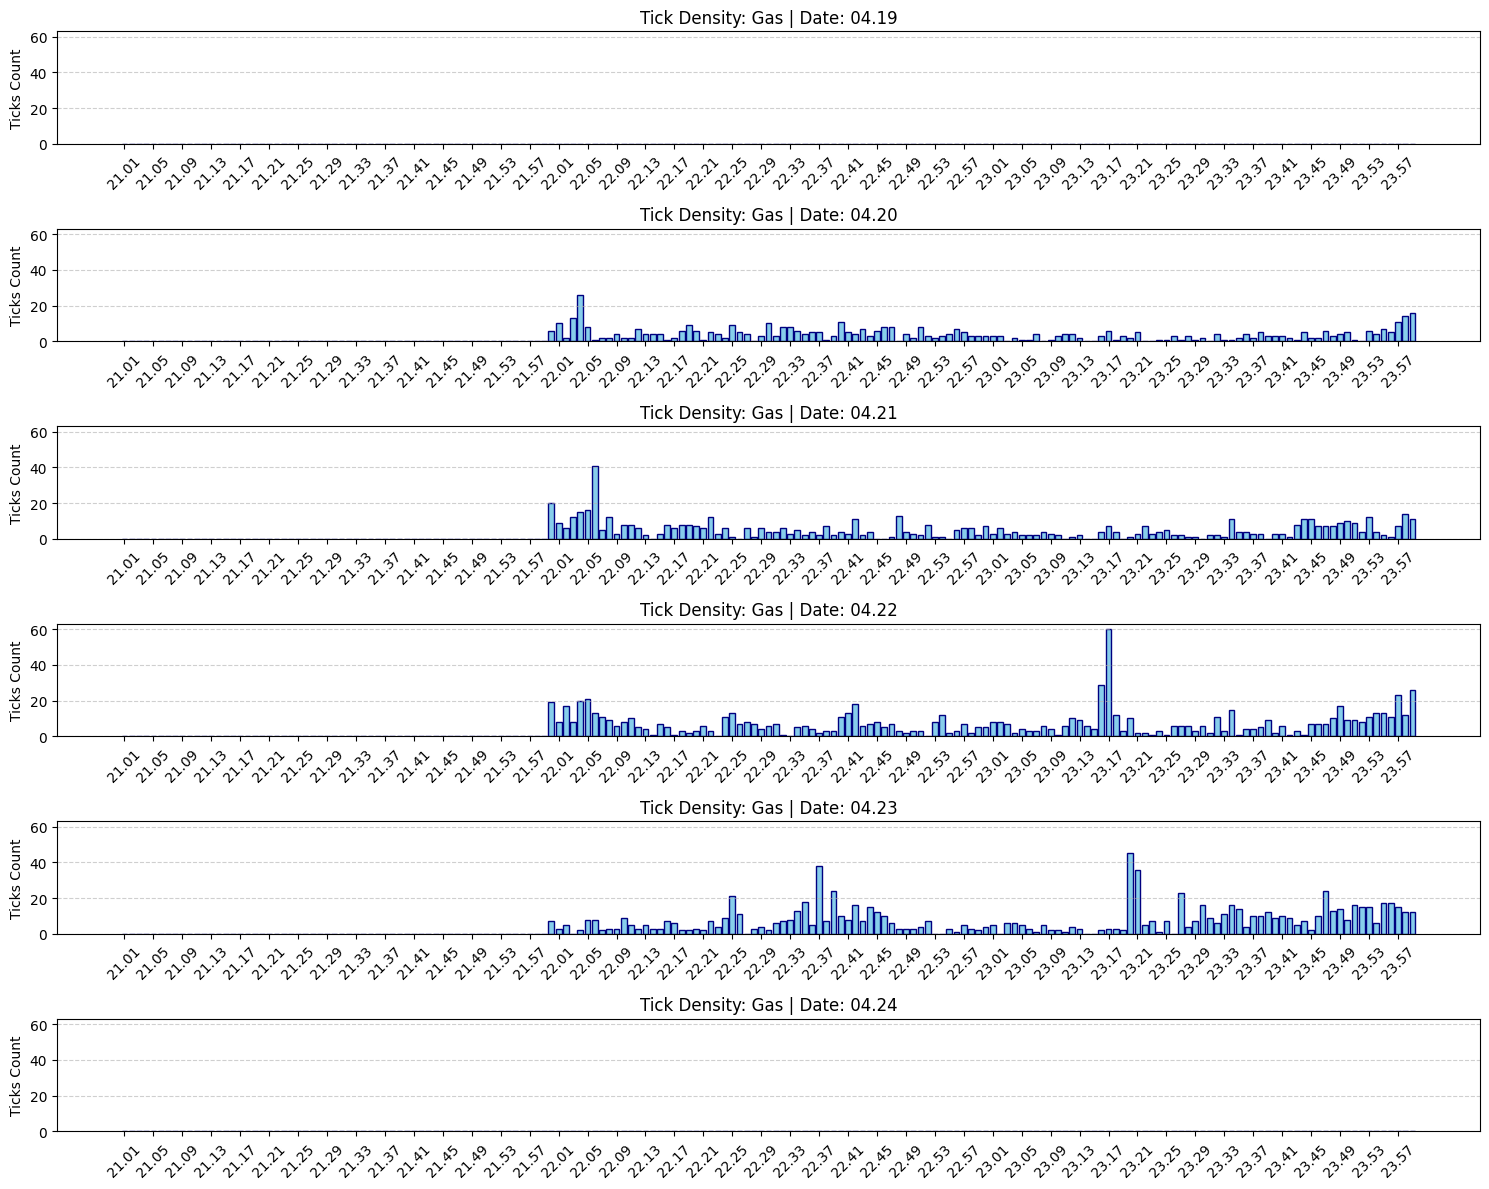

In [40]:
import matplotlib.pyplot as plt

# 1. Настройки фильтрации
target_ticker = 'Gas'          # Тикер для анализа
time_range = "21:00-23:59"      # Промежуток ЧЧ:ММ - ЧЧ:ММ
date_range = "04.19.-04.24."    # Промежуток ДАТ ММ.ДД. - ММ.ДД.

# Парсим настройки
t_start, t_end = time_range.replace(':', '.'), time_range.split('-')[1].replace(':', '.')
d_start, d_end = date_range.split('-')[0], date_range.split('-')[1]

# 2. Получаем уникальные дни из колонок, попадающие в диапазон дат
all_cols = df_density.columns
target_dates = sorted(list(set([c[:6] for c in all_cols if d_start <= c[:6] <= d_end])))

# 3. Построение графиков
fig, axes = plt.subplots(len(target_dates), 1, figsize=(15, 2 * len(target_dates)), sharey=True)
if len(target_dates) == 1: axes = [axes] # Если день один, делаем список для итерации

for i, day_prefix in enumerate(target_dates):
    # Фильтруем колонки для конкретного дня и диапазона времени
    day_cols = [c for c in all_cols if c.startswith(day_prefix) and t_start <= c[6:] <= t_end]
    
    if not day_cols:
        axes[i].set_title(f"No data for {day_prefix}")
        continue
        
    data_to_plot = df_density.loc[target_ticker, day_cols]
    
    # Отрисовка
    axes[i].bar(range(len(data_to_plot)), data_to_plot.values, color='skyblue', edgecolor='navy')
    
    # Настройки осей для каждого дня
    axes[i].set_title(f"Tick Density: {target_ticker} | Date: {day_prefix.strip('.')}", fontsize=12)
    axes[i].set_ylabel("Ticks Count")
    
    # Подписи времени (X) - берем только ЧЧ.ММ из полного названия колонки
    step = max(1, len(day_cols) // 40) # Чтобы не частить с подписями
    axes[i].set_xticks(range(0, len(day_cols), step))
    axes[i].set_xticklabels([c[6:] for c in day_cols[::step]], rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Настройки
target_ticker = 'Wheat'  # Пример тикера с двумя сессиями
date_range = "04.19.-04.24."

# Получаем строку расписания из вашего DF (df_outside_with_stats или df_total_report_enriched)
# Берем первую попавшуюся запись для этого тикера
try:
    raw_sched = df_outside_with_stats[df_outside_with_stats['Ticker'] == target_ticker]['Schedule_Applied'].iloc[0]
except:
    raw_sched = "00:00-23:59" # Дефолт, если не нашли

# Парсим сессии (разделяем по <br> и затем по дефису)
sessions = []
for part in raw_sched.split('<br>'):
    if '-' in part:
        start_t, end_t = part.split('-')
        sessions.append((start_t.strip().replace(':', '.'), end_t.strip().replace(':', '.')))

# 2. Подготовка дат и осей
all_cols = df_density.columns
target_dates = sorted(list(set([c[:6] for c in all_cols if d_start <= c[:6] <= d_end])))

fig, axes = plt.subplots(len(target_dates), 1, figsize=(15, 2 * len(target_dates)), sharey=True)
if len(target_dates) == 1: axes = [axes]

for i, day_prefix in enumerate(target_dates):
    day_cols = [c for c in all_cols if c.startswith(day_prefix)]
    if not day_cols: continue
    
    data_to_plot = df_density.loc[target_ticker, day_cols]
    times_only = [c[6:] for c in day_cols]
    
    # Отрисовка данных
    axes[i].bar(range(len(data_to_plot)), data_to_plot.values, color='skyblue', log=True, zorder=3)
    
    # 3. ЛОГИКА ЗАЛИВКИ (Inverse Session Mask)
    # Создаем маску: по умолчанию все время "вне сессии" (True)
    outside_mask = [True] * len(times_only)
    
    for s_start, s_end in sessions:
        for idx, t in enumerate(times_only):
            if s_start <= t <= s_end:
                outside_mask[idx] = False # Это время внутри одной из сессий
        
        # Рисуем границы сессий
        if s_start in times_only:
            axes[i].axvline(times_only.index(s_start), color='red', linestyle='--', alpha=0.6, zorder=4)
        if s_end in times_only:
            axes[i].axvline(times_only.index(s_end), color='red', linestyle='--', alpha=0.6, zorder=4)

    # Закрашиваем только те участки, где outside_mask == True
    # Для этого ищем непрерывные интервалы True
    start_idx = None
    for idx, is_outside in enumerate(outside_mask):
        if is_outside and start_idx is None:
            start_idx = idx
        elif not is_outside and start_idx is not None:
            axes[i].axvspan(start_idx, idx - 1, color='gray', alpha=0.2, zorder=1)
            start_idx = None
    if start_idx is not None: # Докрашиваем до конца дня, если нужно
        axes[i].axvspan(start_idx, len(outside_mask) - 1, color='gray', alpha=0.2, zorder=1)

    # Оформление
    axes[i].set_title(f"Ticker: {target_ticker} | Date: {day_prefix} | Schedule: {raw_sched.replace('<br>', ' & ')}")
    step = max(1, len(day_cols) // 24)
    axes[i].set_xticks(range(0, len(day_cols), step))
    axes[i].set_xticklabels(times_only[::step], rotation=45)
    axes[i].grid(True, which="both", axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Настройки фильтрации
target_ticker = 'CHINA50'          # Тикер для анализа
time_range = "00:00-23:59"      # Промежуток ЧЧ:ММ - ЧЧ:ММ
date_range = "04.19.-04.24."    # Промежуток ДАТ ММ.ДД. - ММ.ДД.

# Парсим настройки
t_start = time_range.split('-')[0].replace(':', '.')
t_end = time_range.split('-')[1].replace(':', '.')
d_start, d_end = date_range.split('-')[0], date_range.split('-')[1]

# 2. Получаем уникальные дни
all_cols = df_density.columns
target_dates = sorted(list(set([c[:6] for c in all_cols if d_start <= c[:6] <= d_end])))

# 3. Построение графиков
fig, axes = plt.subplots(len(target_dates), 1, figsize=(15, 2 * len(target_dates)), sharey=True)
if len(target_dates) == 1: axes = [axes]

for i, day_prefix in enumerate(target_dates):
    day_cols = [c for c in all_cols if c.startswith(day_prefix) and t_start <= c[6:] <= t_end]
    
    if not day_cols:
        axes[i].set_title(f"No data for {day_prefix}")
        continue
        
    data_to_plot = df_density.loc[target_ticker, day_cols]
    
    # Отрисовка. Используем логарифмическую шкалу для оси Y
    axes[i].bar(range(len(data_to_plot)), data_to_plot.values, color='skyblue', edgecolor='navy', log=True)
    
    # Альтернативный способ задания логарифмической шкалы:
    # axes[i].set_yscale('log') 

    axes[i].set_title(f"Log Scale Tick Density: {target_ticker} | Date: {day_prefix.strip('.')}", fontsize=12)
    axes[i].set_ylabel("Ticks Count (Log Scale)")
    
    # Подписи времени
    step = max(1, len(day_cols) // 20)
    axes[i].set_xticks(range(0, len(day_cols), step))
    axes[i].set_xticklabels([c[6:] for c in day_cols[::step]], rotation=45)
    
    # Добавляем сетку для логарифмических делений
    axes[i].grid(True, which="both", axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:


target_symbol = 'Gasoil'
df_report = get_symbol_violations_report_v2(df_gaps, df_extra, target_symbol)
imported["pd_set_option"](f"Отчет по нарушениям: {target_symbol}", df_report, 50)

In [47]:
def analyze_anomaly_typicality(df_all_violations):
    if df_all_violations.empty:
        return pd.DataFrame()

    df = df_all_violations.copy()
    
    # --- ИСПРАВЛЕНИЕ ОШИБКИ: Унификация названия колонки ---
    # Проверяем, какое имя колонки используется в DF
    if 'Gap_Period' in df.columns:
        col_name = 'Gap_Period'
    elif 'Violation_Interval' in df.columns:
        col_name = 'Violation_Interval'
    elif 'Violation_Period' in df.columns:
        col_name = 'Violation_Period'
    else:
        # Если вдруг колонки нет, выведем список доступных для отладки
        raise KeyError(f"Не найдена колонка с интервалом. Доступные колонки: {list(df.columns)}")

    # 1. Извлекаем время начала нарушения
    df['Start_Time'] = df[col_name].astype(str).str.split('-').str[0]
    
    # Проверка на наличие колонки Position (если ее еще нет)
    if 'Position' not in df.columns:
        df['Position'] = 'N/A'

    # 2. Группируем по времени, типу и позиции
    # Используем только те колонки, которые гарантированно есть
    group_cols = ['Start_Time', 'Type', 'Position']
    
    patterns = df.groupby(group_cols).agg({
        'Ticker': ['count', lambda x: ', '.join(x.unique()[:5]) + ('...' if len(x.unique()) > 5 else '')],
        'Duration_Min': 'mean'
    }).reset_index()
    
    # Плоские имена колонок после агрегации
    patterns.columns = ['Start_Time', 'Type', 'Position', 'Occurrences', 'Example_Tickers', 'Avg_Duration']
    
    # 3. Сортировка и классификация
    patterns = patterns.sort_values(by='Occurrences', ascending=False)
    
    # Считаем типичными те, что повторились более 5 раз (можно настроить)
    threshold = 5 
    patterns['Typicality'] = patterns['Occurrences'].apply(
        lambda x: 'Systemic / Typical' if x >= threshold else 'Random / Unique'
    )
    return patterns

df_total_report = pd.concat([df_gaps, df_extra], ignore_index=True)

In [48]:
# Применяем к объединенному датафрейму по всем символам
df_all_patterns = analyze_anomaly_typicality(df_total_report)

In [49]:
imported["pd_set_option"]("Анализ типичности нарушений", df_all_patterns, 50)


Анализ типичности нарушений  (1,324 строк × 7 колонок)


,Start_Time,Type,Position,Occurrences,Example_Tickers,Avg_Duration,Typicality
1323,nan,Outside Session,N/A,666,"AUS200, BEL20, CA60, CAC40, CAN60...",4.638138,Systemic / Typical
1250,22:00,Gap in Session,N/A,41,"AEX25, AUS200, CAC40, DJI, ESTX50...",76.634146,Systemic / Typical
96,01:38,Gap in Session,N/A,23,"AEX25, Copper, CornX, Cotton, ESTX50...",1.347826,Systemic / Typical
237,03:59,Gap in Session,N/A,23,"AEX25, CAC40, Cotton, ESTX50, EUR50...",1.260870,Systemic / Typical
236,03:58,Gap in Session,N/A,19,"AEX25, CAC40, Cotton, ESTX50, EUR50...",1.631579,Systemic / Typical
267,04:29,Gap in Session,N/A,19,"AEX25, CAC40, CHINA50, ESTX50, EUR50...",1.368421,Systemic / Typical
240,04:02,Gap in Session,N/A,18,"AEX25, CAC40, CHINA50, CornX, ESTX50...",2.444444,Systemic / Typical
344,05:47,Gap in Session,N/A,18,"AEX25, CAC40, ESTX50, EUR50, IBEX...",1.111111,Systemic / Typical
398,06:41,Gap in Session,N/A,18,"CornX, Cotton, IBEX, KOSPI, OMXS30...",4.055556,Systemic / Typical
256,04:18,Gap in Session,N/A,18,"AEX25, CHINA50, Cotton, Gasoil, IBEX...",1.111111,Systemic / Typical


In [50]:
def get_symbol_violations_report(df_gaps, df_extra, target_ticker):
    """
    Собирает все типы нарушений по конкретному тикеру в одну таблицу.
    """
    # 1. Фильтруем оба датафрейма по нужному тикеру
    gaps_sub = df_gaps[df_gaps['Ticker'] == target_ticker]
    extra_sub = df_extra[df_extra['Ticker'] == target_ticker]
    
    # 2. Приводим колонки к единому названию для объединения
    # В df_gaps колонка называется 'Gap_Period', в df_extra — 'Violation_Period'
    # Переименуем их в общее 'Activity_Period'
    gaps_sub = gaps_sub.rename(columns={'Gap_Period': 'Violation_Interval'})
    extra_sub = extra_sub.rename(columns={'Violation_Period': 'Violation_Interval'})
    
    # 3. Объединяем таблицы
    combined_df = pd.concat([gaps_sub, extra_sub], ignore_index=True)
    
    # Если данных нет, возвращаем пустой DF с нужными колонками
    if combined_df.empty:
        return pd.DataFrame(columns=['Violation_Interval', 'Duration_Min', 'Schedule_Applied', 'Weekday', 'Type'])

    # 4. Выбираем только нужные колонки
    final_cols = ['Violation_Interval', 'Duration_Min', 'Schedule_Applied', 'Weekday', 'Type']
    combined_df = combined_df[final_cols]
    
    # 5. Хронологическая сортировка
    # Сначала по дню недели, затем по времени начала нарушения
    combined_df['sort_time'] = combined_df['Violation_Interval'].str.split('-').str[0]
    combined_df = combined_df.sort_values(by=['Weekday', 'sort_time']).drop(columns=['sort_time'])
    
    return combined_df

# --- Пример использования ---
target_symbol = 'TOPIX'
df_report = get_symbol_violations_report(df_gaps, df_extra, target_symbol)
imported["pd_set_option"](f"Отчет по нарушениям: {target_symbol}", df_report, 50)

# Вывод в Jupyter или сохранение в HTML
# df_to_html(df_report, f"Отчет по нарушениям: {target_symbol}", f"report_{target_symbol}")


Отчет по нарушениям: TOPIX  (21 строк × 5 колонок)


,Violation_Interval,Duration_Min,Schedule_Applied,Weekday,Type
0,00:00-00:00,1,00:15-02:44<br>03:45-06:30,1,Outside Session
1,02:45-02:45,1,00:15-02:44<br>03:45-06:30,1,Outside Session
2,06:31-06:40,10,00:15-02:44<br>03:45-06:30,1,Outside Session
3,06:45-06:45,1,00:15-02:44<br>03:45-06:30,1,Outside Session
4,00:00-00:00,1,00:15-02:44<br>03:45-06:30,2,Outside Session
5,02:45-02:45,1,00:15-02:44<br>03:45-06:30,2,Outside Session
6,06:31-06:40,10,00:15-02:44<br>03:45-06:30,2,Outside Session
7,06:45-06:45,1,00:15-02:44<br>03:45-06:30,2,Outside Session
8,00:00-00:00,1,00:15-02:44<br>03:45-06:30,3,Outside Session
9,02:45-02:45,1,00:15-02:44<br>03:45-06:30,3,Outside Session
